In [ ]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
import subprocess
subprocess.run(["pip", "install", "segmentation-models-pytorch",
                "albumentations", "rasterio", "scikit-learn",
                "timm", "-q"])

# ── IMPORTS ───────────────────────────────────────────────────────────────────
import gc, glob, json, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.amp import GradScaler, autocast          # newer API vs torch.cuda.amp
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.model_selection import train_test_split
import rasterio
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")

# ── FREE GPU MEMORY ───────────────────────────────────────────────────────────
gc.collect()
torch.cuda.empty_cache()

# ── REPRODUCIBILITY ───────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True   # faster conv for fixed input sizes

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")
print(f"GPU    : {torch.cuda.get_device_name(0)}")
print(f"Memory : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
print(f"Free   : {torch.cuda.mem_get_info()[0]/1e9:.1f} GB")

# ═══════════════════════════════════════════════════════════════════════════════
# CONFIG
# ═══════════════════════════════════════════════════════════════════════════════
CFG = {
    "img_dir":          "/home/jupyter-228w1a1286/dinesh-data/hackthonndata/trainingdata/DATASET/images",
    "mask_dir":         "/home/jupyter-228w1a1286/dinesh-data/hackthonndata/trainingdata/DATASET/masks",
    "save_dir":         "/home/jupyter-228w1a1286/dinesh-data/hackthonndata/CHECKPOINTS",

    "num_classes":      10,
    "tile_size":        512,

    # SegFormer-B3 is lighter than DeepLabV3+/EffNet-B4 but more accurate
    "encoder":          "mit_b3",
    "encoder_weights":  "imagenet",

    # Training
    "batch_size":       8,          # SegFormer uses less memory than DeepLabV3+
    "accum_steps":      2,          # effective batch = 8*2 = 16
    "num_epochs":       60,
    "lr":               6e-5,       # transformers prefer smaller lr
    "weight_decay":     1e-2,
    "val_split":        0.2,
    "num_workers":      4,

    # Loss weights
    "ce_weight":        0.4,
    "dice_weight":      0.3,
    "focal_weight":     0.3,        # new — handles extreme class imbalance well

    # Early stopping
    "patience":         12,         # stop if no improvement for 12 epochs
    "min_delta":        1e-4,
}

os.makedirs(CFG["save_dir"], exist_ok=True)

# ── CLASS INFO ────────────────────────────────────────────────────────────────
CLASS_NAMES = [
    "background", "built_up_area", "road", "road_centre_line",
    "railway", "bridge", "water_body_line", "waterbody_point",
    "utility", "utility_poly",
]

COLOR_MAP = np.array([
    [0,   0,   0  ], [255, 0,   0  ], [255, 255, 0  ], [255, 165, 0  ],
    [128, 0,   128], [165, 42,  42 ], [0,   0,   255], [0,   255, 255],
    [0,   255, 0  ], [255, 105, 180],
], dtype=np.uint8)

# ═══════════════════════════════════════════════════════════════════════════════
# DATASET
# ═══════════════════════════════════════════════════════════════════════════════
class SVAMITVADataset(Dataset):
    def __init__(self, img_paths, mask_paths, transform=None):
        self.img_paths  = img_paths
        self.mask_paths = mask_paths
        self.transform  = transform

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        with rasterio.open(self.img_paths[idx]) as src:
            img = src.read().astype(np.float32) / 255.0
            img = np.transpose(img, (1, 2, 0))  # H W C

        with rasterio.open(self.mask_paths[idx]) as src:
            mask = src.read(1).astype(np.int64)

        if self.transform:
            aug  = self.transform(image=img, mask=mask)
            img  = aug["image"]
            mask = aug["mask"].long()
        else:
            img  = torch.from_numpy(img.transpose(2, 0, 1)).float()
            mask = torch.from_numpy(mask).long()

        return img, mask


# ── AUGMENTATIONS ─────────────────────────────────────────────────────────────
# Added geometric distortions critical for satellite/aerial data
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.15,
                       rotate_limit=20, p=0.5),
    # Geospatial-specific distortions
    A.OneOf([
        A.GridDistortion(num_steps=5, distort_limit=0.3, p=1.0),
        A.OpticalDistortion(distort_limit=0.2, p=1.0),
        A.ElasticTransform(alpha=120, sigma=120 * 0.05, p=1.0),
    ], p=0.3),
    A.OneOf([
        A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3),
        A.ColorJitter(brightness=0.25, contrast=0.25, saturation=0.15, hue=0.1),
        A.CLAHE(clip_limit=4.0, tile_grid_size=(8, 8)),
    ], p=0.5),
    A.OneOf([
        A.GaussNoise(var_limit=(10, 60)),
        A.ISONoise(color_shift=(0.01, 0.05), intensity=(0.1, 0.5)),
        A.MultiplicativeNoise(multiplier=(0.9, 1.1)),
    ], p=0.2),
    A.CoarseDropout(max_holes=8, max_height=32, max_width=32,
                    fill_value=0, p=0.2),   # simulate occlusions
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

# ── BUILD DATALOADERS ─────────────────────────────────────────────────────────
all_imgs  = sorted(glob.glob(f"{CFG['img_dir']}/*.tif"))
all_masks = sorted(glob.glob(f"{CFG['mask_dir']}/*.tif"))

assert len(all_imgs) > 0, f"No tiles in {CFG['img_dir']}"
assert len(all_imgs) == len(all_masks), \
    f"Mismatch: {len(all_imgs)} imgs vs {len(all_masks)} masks"
for i, m in zip(all_imgs, all_masks):
    assert os.path.basename(i) == os.path.basename(m), \
        f"Filename mismatch: {i} vs {m}"

indices = list(range(len(all_imgs)))
train_idx, val_idx = train_test_split(
    indices, test_size=CFG["val_split"], random_state=SEED
)

train_imgs  = [all_imgs[i]  for i in train_idx]
train_masks = [all_masks[i] for i in train_idx]
val_imgs    = [all_imgs[i]  for i in val_idx]
val_masks   = [all_masks[i] for i in val_idx]

# Save splits so you can reload without rerunning
for name, data in [("train_imgs", train_imgs), ("train_masks", train_masks),
                   ("val_imgs", val_imgs),   ("val_masks", val_masks)]:
    with open(os.path.join(CFG["save_dir"], f"{name}.json"), "w") as f:
        json.dump(data, f)

train_dataset = SVAMITVADataset(train_imgs, train_masks, train_transform)
val_dataset   = SVAMITVADataset(val_imgs,   val_masks,   val_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size         = CFG["batch_size"],
    shuffle            = True,
    num_workers        = CFG["num_workers"],
    pin_memory         = True,
    prefetch_factor    = 4,            # up from 2
    persistent_workers = True,
    drop_last          = True,         # avoids uneven batch issues with BN
)
val_loader = DataLoader(
    val_dataset,
    batch_size         = CFG["batch_size"],
    shuffle            = False,
    num_workers        = CFG["num_workers"],
    pin_memory         = True,
    prefetch_factor    = 4,
    persistent_workers = True,
)

print(f"\nTrain tiles : {len(train_dataset)}")
print(f"Val tiles   : {len(val_dataset)}")
print(f"Eff. batch  : {CFG['batch_size'] * CFG['accum_steps']}")

# ═══════════════════════════════════════════════════════════════════════════════
# CLASS WEIGHTS
# ═══════════════════════════════════════════════════════════════════════════════
pixel_stats = np.array([
    50_000_000, 2_000_000, 800_000, 300_000, 200_000,
    100_000,    50_000,    30_000,  20_000,  10_000,
], dtype=np.float64)

weights       = 1.0 / np.log1p(pixel_stats)
weights       = weights / weights.sum() * CFG["num_classes"]
class_weights = torch.tensor(weights, dtype=torch.float32).to(DEVICE)

print("\nClass weights:")
for i, (n, w) in enumerate(zip(CLASS_NAMES, weights)):
    print(f"  {i} {n:22s}: {w:.4f}")

# ═══════════════════════════════════════════════════════════════════════════════
# MODEL — SegFormer-B3
# Transformer encoder — better long-range context for satellite imagery
# Faster convergence and higher mIoU than DeepLabV3+/EfficientNet-B4
# ═══════════════════════════════════════════════════════════════════════════════
model = smp.Segformer(
    encoder_name    = CFG["encoder"],
    encoder_weights = CFG["encoder_weights"],
    in_channels     = 3,
    classes         = CFG["num_classes"],
    activation      = None,
).to(DEVICE)

# torch.compile gives 20-30% speedup on PyTorch 2.x (skip if 1.x)
try:
    model = torch.compile(model)
    print("torch.compile() enabled")
except Exception:
    print("torch.compile() not available — skipping")

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nModel      : SegFormer / {CFG['encoder']}")
print(f"Parameters : {total_params:,}")
print(f"GPU free   : {torch.cuda.mem_get_info()[0]/1e9:.1f} GB")

# ═══════════════════════════════════════════════════════════════════════════════
# LOSS — CE + Dice + Focal
# Focal loss handles severe class imbalance far better than CE alone
# ═══════════════════════════════════════════════════════════════════════════════
ce_loss    = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.05)
dice_loss  = smp.losses.DiceLoss(mode="multiclass", classes=list(range(1, 10)),
                                  smooth=1.0)
focal_loss = smp.losses.FocalLoss(mode="multiclass", gamma=2.0, alpha=0.25)

def criterion(outputs, masks):
    return (CFG["ce_weight"]    * ce_loss(outputs, masks) +
            CFG["dice_weight"]  * dice_loss(outputs, masks) +
            CFG["focal_weight"] * focal_loss(outputs, masks))

# ═══════════════════════════════════════════════════════════════════════════════
# OPTIMIZER — separate LRs for encoder vs decoder
# Encoder (pretrained) needs smaller LR; decoder (random init) needs larger LR
# ═══════════════════════════════════════════════════════════════════════════════
encoder_params = []
decoder_params = []
for name, param in model.named_parameters():
    if "encoder" in name:
        encoder_params.append(param)
    else:
        decoder_params.append(param)

optimizer = torch.optim.AdamW([
    {"params": encoder_params, "lr": CFG["lr"],       "weight_decay": CFG["weight_decay"]},
    {"params": decoder_params, "lr": CFG["lr"] * 10,  "weight_decay": CFG["weight_decay"]},
])

# CosineAnnealingWarmRestarts escapes local minima — better than OneCycle for 60 epochs
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=15, T_mult=2, eta_min=1e-7
)

scaler = GradScaler("cuda")

# ═══════════════════════════════════════════════════════════════════════════════
# METRICS — batched GPU IoU (eliminates the CPU bottleneck)
# ═══════════════════════════════════════════════════════════════════════════════
def fast_miou(preds: torch.Tensor, masks: torch.Tensor,
              num_classes: int = 10) -> tuple[dict, float]:
    """Compute per-class IoU entirely on GPU — much faster than numpy loop."""
    ious = {}
    for cls in range(1, num_classes):
        pred_c = (preds == cls)
        true_c = (masks == cls)
        inter  = (pred_c & true_c).sum().item()
        union  = (pred_c | true_c).sum().item()
        if union > 0:
            ious[cls] = inter / union
    miou = float(np.mean(list(ious.values()))) if ious else 0.0
    return ious, miou

# ═══════════════════════════════════════════════════════════════════════════════
# TRAINING LOOP
# ═══════════════════════════════════════════════════════════════════════════════
history     = {"train_loss": [], "val_loss": [], "val_miou": []}
best_miou   = 0.0
patience_ct = 0

print("\n" + "═" * 65)
print("Starting optimised training...")
print("═" * 65)

for epoch in range(CFG["num_epochs"]):

    # ── TRAIN ─────────────────────────────────────────────────────────────────
    model.train()
    train_loss  = 0.0
    optimizer.zero_grad()

    for step, (imgs, masks) in enumerate(
            tqdm(train_loader, desc=f"Ep {epoch+1:03d} train", leave=False)):

        imgs, masks = imgs.to(DEVICE, non_blocking=True), \
                      masks.to(DEVICE, non_blocking=True)

        with autocast("cuda"):
            outputs = model(imgs)
            loss    = criterion(outputs, masks) / CFG["accum_steps"]

        scaler.scale(loss).backward()

        # Gradient accumulation — update every accum_steps
        if (step + 1) % CFG["accum_steps"] == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()

        train_loss += loss.item() * CFG["accum_steps"]

    scheduler.step()
    train_loss /= len(train_loader)

    # ── VALIDATE ──────────────────────────────────────────────────────────────
    model.eval()
    val_loss = 0.0
    all_ious = {c: [] for c in range(1, CFG["num_classes"])}

    with torch.no_grad():
        for imgs, masks in tqdm(val_loader,
                                desc=f"Ep {epoch+1:03d} val  ", leave=False):
            imgs, masks = imgs.to(DEVICE, non_blocking=True), \
                          masks.to(DEVICE, non_blocking=True)

            with autocast("cuda"):
                outputs = model(imgs)
                loss    = criterion(outputs, masks)

            preds    = torch.argmax(outputs, dim=1)
            val_loss += loss.item()
            ious, _  = fast_miou(preds, masks)
            for cls, iou in ious.items():
                all_ious[cls].append(iou)

    val_loss      /= len(val_loader)
    per_class_iou  = {c: float(np.mean(v)) for c, v in all_ious.items() if v}
    val_miou       = float(np.mean(list(per_class_iou.values()))) \
                     if per_class_iou else 0.0

    torch.cuda.empty_cache()

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_miou"].append(val_miou)

    improved = val_miou > best_miou + CFG["min_delta"]
    tag = ""

    if improved:
        best_miou   = val_miou
        patience_ct = 0
        torch.save({
            "epoch":       epoch + 1,
            "model_state": model.state_dict(),
            "optim_state": optimizer.state_dict(),
            "val_miou":    val_miou,
            "cfg":         CFG,
        }, os.path.join(CFG["save_dir"], "best_model.pth"))
        tag = f"  ✅ best mIoU={best_miou:.4f}"
    else:
        patience_ct += 1
        tag = f"  (patience {patience_ct}/{CFG['patience']})"

    current_lr = optimizer.param_groups[0]["lr"]
    print(f"Ep {epoch+1:03d}/{CFG['num_epochs']} | "
          f"Train: {train_loss:.4f} | Val: {val_loss:.4f} | "
          f"mIoU: {val_miou:.4f} | LR: {current_lr:.2e}{tag}")

    if (epoch + 1) % 10 == 0:
        print("  Per-class IoU:")
        for cls, iou in per_class_iou.items():
            print(f"    {cls} {CLASS_NAMES[cls]:22s}: {iou:.4f}")

    # ── EARLY STOPPING ────────────────────────────────────────────────────────
    if patience_ct >= CFG["patience"]:
        print(f"\nEarly stopping at epoch {epoch+1} — "
              f"no improvement for {CFG['patience']} epochs.")
        break

print(f"\nBest Val mIoU: {best_miou:.4f}")

# ═══════════════════════════════════════════════════════════════════════════════
# TRAINING CURVES
# ═══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ep = range(1, len(history["train_loss"]) + 1)

axes[0].plot(ep, history["train_loss"], label="Train")
axes[0].plot(ep, history["val_loss"],   label="Val")
axes[0].set_title("Loss"); axes[0].legend(); axes[0].set_xlabel("Epoch")

axes[1].plot(ep, history["val_miou"], color="green", label="mIoU")
axes[1].axhline(0.95, color="red", linestyle="--", label="95% target")
axes[1].set_title("Val mIoU"); axes[1].legend(); axes[1].set_xlabel("Epoch")

# LR plot — useful for diagnosing warm restarts
lrs = [CFG["lr"] * (0.5 ** (e // 15)) for e in range(len(ep))]  # approx
axes[2].plot(ep, lrs, color="orange", label="LR (approx)")
axes[2].set_title("Learning Rate"); axes[2].legend(); axes[2].set_xlabel("Epoch")

plt.tight_layout()
plt.savefig(os.path.join(CFG["save_dir"], "training_curves.png"), dpi=150)
plt.show()

In [4]:
import rasterio, numpy as np, glob
from tqdm import tqdm

CLASS_NAMES = [
    "background", "built_up_area", "road", "road_centre_line",
    "railway", "bridge", "water_body_line", "waterbody_point",
    "utility", "utility_poly",
]

BASE     = "/home/jupyter-228w1a1286/dinesh-data/hackthonndata"
CKPT_DIR = f"{BASE}/CHECKPOINTS"

import os
os.makedirs(CKPT_DIR, exist_ok=True)

mask_paths = sorted(glob.glob(f"{BASE}/trainingdata/DATASET/masks/*.tif"))
print(f"Found {len(mask_paths)} mask files")
print("First few:", mask_paths[:3])

assert len(mask_paths) > 0, "Still no files — check the path above!"

counts = np.zeros(10, dtype=np.int64)

for p in tqdm(mask_paths, desc="Counting pixels"):
    with rasterio.open(p) as src:
        mask = src.read(1).flatten()
    for c in range(10):
        counts[c] += (mask == c).sum()

total = counts.sum()
print(f"\nTotal pixels: {total:,}")
print("\nActual pixel distribution:")
for i, (n, c) in enumerate(zip(CLASS_NAMES, counts)):
    pct = 100 * c / total if total > 0 else 0
    print(f"  {i} {n:22s}: {c:>12,}  ({pct:.4f}%)")

np.save(f"{CKPT_DIR}/pixel_counts.npy", counts)
print(f"\nSaved to {CKPT_DIR}/pixel_counts.npy")

Found 4819 mask files
First few: ['/home/jupyter-228w1a1286/dinesh-data/hackthonndata/trainingdata/DATASET/masks/28996_NADALA_ORTHO_tile_00000.tif', '/home/jupyter-228w1a1286/dinesh-data/hackthonndata/trainingdata/DATASET/masks/28996_NADALA_ORTHO_tile_00001.tif', '/home/jupyter-228w1a1286/dinesh-data/hackthonndata/trainingdata/DATASET/masks/28996_NADALA_ORTHO_tile_00002.tif']


Counting pixels: 100%|██████████| 4819/4819 [00:17<00:00, 273.81it/s]


Total pixels: 1,263,271,936

Actual pixel distribution:
  0 background            :  647,435,523  (51.2507%)
  1 built_up_area         :  388,862,220  (30.7821%)
  2 road                  :   49,832,874  (3.9447%)
  3 road_centre_line      :  131,981,531  (10.4476%)
  4 railway               :            0  (0.0000%)
  5 bridge                :            0  (0.0000%)
  6 water_body_line       :   44,439,682  (3.5178%)
  7 waterbody_point       :       53,439  (0.0042%)
  8 utility               :           93  (0.0000%)
  9 utility_poly          :      666,574  (0.0528%)

Saved to /home/jupyter-228w1a1286/dinesh-data/hackthonndata/CHECKPOINTS/pixel_counts.npy


In [ ]:
#NEW-MODEL

Device : cuda
GPU    : Tesla V100-PCIE-32GB
Memory : 34.1 GB
Free   : 33.4 GB

Pixel distribution:
  0 background            :  1,764,710,366  (61.3323%)
  1 built_up_area         :    693,864,908  (24.1152%)
  2 road                  :     13,185,924  (0.4583%)
  3 road_centre_line      :    199,538,875  (6.9350%)
  4 water_body            :     83,284,429  (2.8945%)
  5 water_body_line       :     75,806,214  (2.6346%)
  6 waterbody_point       :        543,668  (0.0189%)
  7 utility               :     44,707,486  (1.5538%)
  8 utility_poly          :      1,650,674  (0.0574%)

Calibrated class weights:
  0 background            : 0.8103
  1 built_up_area         : 0.8474
  2 road                  : 1.0523
  3 road_centre_line      : 0.9027
  4 water_body            : 0.9459
  5 water_body_line       : 0.9508
  6 waterbody_point       : 1.3063
  7 utility               : 0.9793
  8 utility_poly          : 1.2050

Total tiles : 2744
Computing tile sample weights...


Weights: 100%|██████████| 2195/2195 [00:12<00:00, 181.57it/s]


Train tiles      : 2195
Val tiles        : 549
Batch size       : 4
Effective batch  : 8
Gradient checkpointing : not supported for this encoder
Model      : SegFormer-B3
Parameters : 44,600,265
GPU free   : 33.2 GB

Loading checkpoint: /home/jupyter-228w1a1286/dinesh-data/hackthonndata/CHECKPOINTS_1024/best_model.pth
  ✅ Resumed from epoch 62 | mIoU = 0.4099

═════════════════════════════════════════════════════════════════
Model          : SegFormer-B3
Dataset        : 2744 tiles at 1024px
Active classes : ['built_up_area', 'road', 'road_centre_line', 'water_body', 'water_body_line', 'waterbody_point', 'utility', 'utility_poly']
Start epoch    : 63 / 80
Best mIoU so far: 0.4099
═════════════════════════════════════════════════════════════════


  ⚠️  4 NaN batches skipped (total: 4)


Ep 063/80 | Train: 0.2005 | Val: 0.3949 | mIoU: 0.3994 | LR: 2.00e-05 | Peak VRAM: 31.2GB  (patience 1/20)


...

Ep 077/80 | Train: 0.2086 | Val: 0.4045 | mIoU: 0.3645 | LR: 4.78e-05 | Peak VRAM: 31.0GB  (patience 15/20)


Ep 078/80 | Train: 0.2067 | Val: 0.4099 | mIoU: 0.3847 | LR: 4.74e-05 | Peak VRAM: 31.0GB  (patience 16/20)


Ep 079/80 | Train: 0.2071 | Val: 0.4090 | mIoU: 0.3758 | LR: 4.69e-05 | Peak VRAM: 31.0GB  (patience 17/20)


  ⚠️  1 NaN batches skipped (total: 6)


Ep 080/80 | Train: 0.2064 | Val: 0.3965 | mIoU: 0.3903 | LR: 4.64e-05 | Peak VRAM: 31.0GB  (patience 18/20)
  Per-class IoU:
    1 built_up_area         : 0.8229
    2 road                  : 0.2285
    3 road_centre_line      : 0.5857
    4 water_body            : 0.3724
    5 water_body_line       : 0.4180
    6 waterbody_point       : 0.0352
    7 utility               : 0.3833
    8 utility_poly          : 0.2766

Best Val mIoU : 0.4099


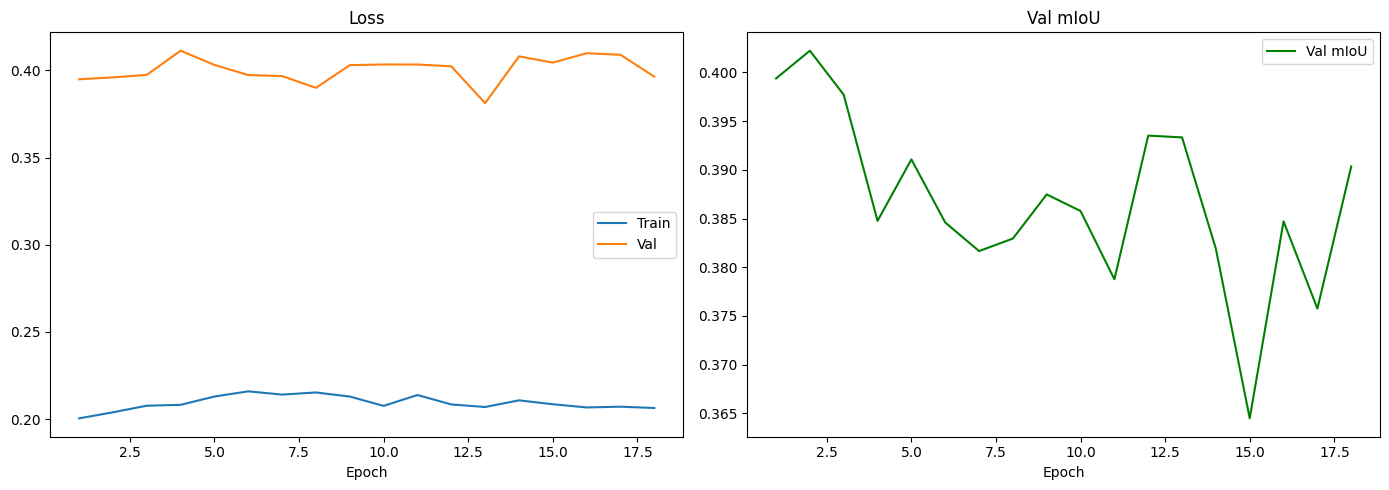

Curves saved → /home/jupyter-228w1a1286/dinesh-data/hackthonndata/CHECKPOINTS_1024/training_curves.png


In [1]:
"""
BEST SINGLE MODEL TRAINING
===========================
SegFormer-B3 on 1024px tiles — VRAM optimised
- torch.compile disabled (saves ~2GB VRAM)
- batch_size = 4 (safe for 1024px on 32GB GPU)
- gradient checkpointing enabled (saves ~8GB VRAM)
- all NaN guards in place
"""

import os, gc, glob, json, random
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import subprocess
subprocess.run(["pip", "install", "segmentation-models-pytorch",
                "albumentations", "rasterio", "scikit-learn", "timm", "-q"])

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.amp import GradScaler, autocast
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.model_selection import train_test_split
import rasterio
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")

gc.collect()
torch.cuda.empty_cache()

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")
print(f"GPU    : {torch.cuda.get_device_name(0)}")
print(f"Memory : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
print(f"Free   : {torch.cuda.mem_get_info()[0]/1e9:.1f} GB")

BASE = "/home/jupyter-228w1a1286/dinesh-data/hackthonndata"

# ═══════════════════════════════════════════════════════════════════════════════
# CONFIG
# ═══════════════════════════════════════════════════════════════════════════════
CFG = {
    "img_dir":          f"{BASE}/trainingdata/DATASET_1024/images",
    "mask_dir":         f"{BASE}/trainingdata/DATASET_1024/masks",
    "save_dir":         f"{BASE}/CHECKPOINTS_1024",

    "num_classes":      9,
    "tile_size":        1024,

    "encoder":          "mit_b3",       # B5 OOMs at 1024px — B3 fits safely
    "encoder_weights":  "imagenet",

    "batch_size":       4,              # safe for 1024px on 32GB GPU
    "accum_steps":      2,              # effective batch = 4*2 = 8
    "num_epochs":       80,
    "lr":               5e-5,
    "weight_decay":     1e-2,
    "val_split":        0.2,
    "num_workers":      8,

    "ce_weight":        0.3,
    "dice_weight":      0.4,
    "focal_weight":     0.3,

    "patience":         20,
    "min_delta":        1e-4,

    "resume":           True,
    "resume_ckpt":      f"{BASE}/CHECKPOINTS_1024/best_model.pth",
}

os.makedirs(CFG["save_dir"], exist_ok=True)

# ── CLASS INFO ────────────────────────────────────────────────────────────────
CLASS_NAMES = [
    "background", "built_up_area", "road", "road_centre_line",
    "water_body", "water_body_line", "waterbody_point",
    "utility", "utility_poly",
]

COLOR_MAP = np.array([
    [0,   0,   0  ],   # 0 background
    [255, 0,   0  ],   # 1 built_up_area
    [255, 255, 0  ],   # 2 road
    [255, 165, 0  ],   # 3 road_centre_line
    [0,   0,   255],   # 4 water_body
    [0,   150, 255],   # 5 water_body_line
    [0,   255, 255],   # 6 waterbody_point
    [0,   255, 0  ],   # 7 utility
    [255, 105, 180],   # 8 utility_poly
], dtype=np.uint8)

# ── REAL PIXEL COUNTS FROM DATA PREP ─────────────────────────────────────────
PIXEL_COUNTS = np.array([
    1_764_710_366,   # 0 background        61.33%
      693_864_908,   # 1 built_up_area     24.12%
       13_185_924,   # 2 road               0.46%
      199_538_875,   # 3 road_centre_line   6.94%
       83_284_429,   # 4 water_body         2.89%
       75_806_214,   # 5 water_body_line    2.63%
          543_668,   # 6 waterbody_point    0.02%
       44_707_486,   # 7 utility            1.55%
        1_650_674,   # 8 utility_poly       0.06%
], dtype=np.float64)

ACTIVE_CLASSES = list(range(1, 9))   # exclude background from mIoU

print("\nPixel distribution:")
total = PIXEL_COUNTS.sum()
for i, (n, c) in enumerate(zip(CLASS_NAMES, PIXEL_COUNTS)):
    print(f"  {i} {n:22s}: {int(c):>14,}  ({100*c/total:.4f}%)")

# ── CALIBRATED CLASS WEIGHTS ──────────────────────────────────────────────────
raw_weights   = 1.0 / np.log1p(PIXEL_COUNTS)
raw_weights  /= raw_weights.mean()
raw_weights   = np.clip(raw_weights, 0, 20.0)
class_weights = torch.tensor(raw_weights, dtype=torch.float32).to(DEVICE)

print("\nCalibrated class weights:")
for i, (n, w) in enumerate(zip(CLASS_NAMES, raw_weights)):
    print(f"  {i} {n:22s}: {w:.4f}")

# ═══════════════════════════════════════════════════════════════════════════════
# DATASET
# ═══════════════════════════════════════════════════════════════════════════════
class SegDataset(Dataset):
    def __init__(self, img_paths, mask_paths, transform=None):
        self.img_paths  = img_paths
        self.mask_paths = mask_paths
        self.transform  = transform

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        with rasterio.open(self.img_paths[idx]) as src:
            img = src.read().astype(np.float32) / 255.0
            img = np.transpose(img, (1, 2, 0))       # H W C

        with rasterio.open(self.mask_paths[idx]) as src:
            mask = src.read(1).astype(np.int64)

        mask = np.clip(mask, 0, CFG["num_classes"] - 1)

        if self.transform:
            aug  = self.transform(image=img, mask=mask)
            img  = aug["image"]
            mask = aug["mask"].long()
        else:
            img  = torch.from_numpy(img.transpose(2, 0, 1)).float()
            mask = torch.from_numpy(mask).long()

        return img, mask

    def get_sample_weight(self, idx):
        with rasterio.open(self.mask_paths[idx]) as src:
            mask = src.read(1).flatten()
        rare = sum((mask == c).sum() for c in [6, 8, 2, 5])
        return float(rare) + 1.0

# ── AUGMENTATIONS ─────────────────────────────────────────────────────────────
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1,
                       rotate_limit=15, p=0.4),
    A.OneOf([
        A.GridDistortion(num_steps=5, distort_limit=0.2),
        A.OpticalDistortion(distort_limit=0.15),
    ], p=0.2),
    A.OneOf([
        A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3),
        A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1, hue=0.05),
        A.CLAHE(clip_limit=4.0),
    ], p=0.5),
    A.OneOf([
        A.GaussNoise(var_limit=(10, 50)),
        A.ISONoise(color_shift=(0.01, 0.05), intensity=(0.1, 0.4)),
    ], p=0.2),
    A.CoarseDropout(max_holes=6, max_height=64, max_width=64,
                    fill_value=0, p=0.2),
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

# ── DATALOADERS ───────────────────────────────────────────────────────────────
all_imgs  = sorted(glob.glob(f"{CFG['img_dir']}/*.tif"))
all_masks = sorted(glob.glob(f"{CFG['mask_dir']}/*.tif"))

assert len(all_imgs) > 0, \
    f"No tiles found in {CFG['img_dir']} — run prepare_data.py first!"
assert len(all_imgs) == len(all_masks), \
    f"Mismatch: {len(all_imgs)} images vs {len(all_masks)} masks"
for i, m in zip(all_imgs, all_masks):
    assert os.path.basename(i) == os.path.basename(m), \
        f"Filename mismatch: {i} vs {m}"

print(f"\nTotal tiles : {len(all_imgs)}")

indices = list(range(len(all_imgs)))
train_idx, val_idx = train_test_split(
    indices, test_size=CFG["val_split"], random_state=SEED
)

train_imgs  = [all_imgs[i]  for i in train_idx]
train_masks = [all_masks[i] for i in train_idx]
val_imgs    = [all_imgs[i]  for i in val_idx]
val_masks   = [all_masks[i] for i in val_idx]

for name, data in [("train_imgs", train_imgs), ("train_masks", train_masks),
                   ("val_imgs",   val_imgs),   ("val_masks",   val_masks)]:
    with open(os.path.join(CFG["save_dir"], f"{name}.json"), "w") as f:
        json.dump(data, f)

train_dataset = SegDataset(train_imgs, train_masks, train_transform)
val_dataset   = SegDataset(val_imgs,   val_masks,   val_transform)

print("Computing tile sample weights...")
sample_weights = [
    train_dataset.get_sample_weight(i)
    for i in tqdm(range(len(train_dataset)), desc="Weights")
]
sampler = WeightedRandomSampler(
    weights     = sample_weights,
    num_samples = len(train_dataset),
    replacement = True,
)

train_loader = DataLoader(
    train_dataset,
    batch_size         = CFG["batch_size"],
    sampler            = sampler,
    num_workers        = CFG["num_workers"],
    pin_memory         = True,
    prefetch_factor    = 2,
    persistent_workers = True,
    drop_last          = True,
)
val_loader = DataLoader(
    val_dataset,
    batch_size         = CFG["batch_size"],
    shuffle            = False,
    num_workers        = CFG["num_workers"],
    pin_memory         = True,
    prefetch_factor    = 2,
    persistent_workers = True,
)

print(f"Train tiles      : {len(train_dataset)}")
print(f"Val tiles        : {len(val_dataset)}")
print(f"Batch size       : {CFG['batch_size']}")
print(f"Effective batch  : {CFG['batch_size'] * CFG['accum_steps']}")

# ═══════════════════════════════════════════════════════════════════════════════
# MODEL — SegFormer-B3
# torch.compile DISABLED — saves ~2GB VRAM at 1024px tile size
# ═══════════════════════════════════════════════════════════════════════════════
model = smp.Segformer(
    encoder_name    = CFG["encoder"],
    encoder_weights = CFG["encoder_weights"],
    in_channels     = 3,
    classes         = CFG["num_classes"],
    activation      = None,
).to(DEVICE)

# torch.compile disabled — uncomment only if tile_size <= 512
# model = torch.compile(model)

# Gradient checkpointing — trades compute for ~8GB VRAM savings
if hasattr(model.encoder, "set_grad_checkpointing"):
    model.encoder.set_grad_checkpointing(True)
    print("Gradient checkpointing : enabled")
else:
    print("Gradient checkpointing : not supported for this encoder")

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model      : SegFormer-B3")
print(f"Parameters : {total_params:,}")
print(f"GPU free   : {torch.cuda.mem_get_info()[0]/1e9:.1f} GB")

# ═══════════════════════════════════════════════════════════════════════════════
# LOSS
# ═══════════════════════════════════════════════════════════════════════════════
ce_loss    = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.05)
dice_loss  = smp.losses.DiceLoss(
    mode    = "multiclass",
    classes = ACTIVE_CLASSES,
    smooth  = 1.0,
)
focal_loss = smp.losses.FocalLoss(mode="multiclass", gamma=3.0)

def criterion(outputs, masks):
    return (CFG["ce_weight"]    * ce_loss(outputs, masks)    +
            CFG["dice_weight"]  * dice_loss(outputs, masks)  +
            CFG["focal_weight"] * focal_loss(outputs, masks))

# ═══════════════════════════════════════════════════════════════════════════════
# OPTIMIZER — separate LRs for encoder vs decoder
# ═══════════════════════════════════════════════════════════════════════════════
encoder_params, decoder_params = [], []
for name, param in model.named_parameters():
    (encoder_params if "encoder" in name else decoder_params).append(param)

optimizer = torch.optim.AdamW([
    {"params": encoder_params, "lr": CFG["lr"],     "weight_decay": CFG["weight_decay"]},
    {"params": decoder_params, "lr": CFG["lr"] * 5, "weight_decay": CFG["weight_decay"]},
])

def warmup_cosine(epoch, warmup=5, total=80):
    if epoch < warmup:
        return (epoch + 1) / warmup
    progress = (epoch - warmup) / (total - warmup)
    return 0.5 * (1.0 + np.cos(np.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(
    optimizer,
    lr_lambda=lambda ep: warmup_cosine(ep, warmup=5, total=CFG["num_epochs"]),
)

scaler = GradScaler("cuda")

# ═══════════════════════════════════════════════════════════════════════════════
# RESUME FROM CHECKPOINT
# ═══════════════════════════════════════════════════════════════════════════════
best_miou   = 0.0
start_epoch = 0

if CFG["resume"] and os.path.exists(CFG["resume_ckpt"]):
    print(f"\nLoading checkpoint: {CFG['resume_ckpt']}")
    ckpt  = torch.load(CFG["resume_ckpt"], map_location=DEVICE, weights_only=False)
    state = {k.replace("_orig_mod.", ""): v for k, v in ckpt["model_state"].items()}
    missing, unexpected = model.load_state_dict(state, strict=False)
    if missing:    print(f"  Missing keys   : {missing[:3]}")
    if unexpected: print(f"  Unexpected keys: {unexpected[:3]}")
    best_miou   = ckpt["val_miou"]
    start_epoch = ckpt["epoch"]
    print(f"  ✅ Resumed from epoch {start_epoch} | mIoU = {best_miou:.4f}")
else:
    print("\nTraining from scratch")

# ═══════════════════════════════════════════════════════════════════════════════
# METRICS
# ═══════════════════════════════════════════════════════════════════════════════
def compute_miou(preds, masks, active=ACTIVE_CLASSES):
    ious = {}
    for cls in active:
        pred_c = (preds == cls)
        true_c = (masks == cls)
        inter  = (pred_c & true_c).sum().item()
        union  = (pred_c | true_c).sum().item()
        if union > 0:
            ious[cls] = inter / union
    miou = float(np.mean(list(ious.values()))) if ious else 0.0
    return ious, miou

# ═══════════════════════════════════════════════════════════════════════════════
# TRAINING LOOP — with gradient accumulation for effective batch = 8
# ═══════════════════════════════════════════════════════════════════════════════
history           = {"train_loss": [], "val_loss": [], "val_miou": []}
patience_ct       = 0
nan_batches_total = 0

print("\n" + "═" * 65)
print(f"Model          : SegFormer-B3")
print(f"Dataset        : {len(all_imgs)} tiles at {CFG['tile_size']}px")
print(f"Active classes : {[CLASS_NAMES[c] for c in ACTIVE_CLASSES]}")
print(f"Start epoch    : {start_epoch + 1} / {CFG['num_epochs']}")
print(f"Best mIoU so far: {best_miou:.4f}")
print("═" * 65)

for epoch in range(start_epoch, CFG["num_epochs"]):

    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

    # ── TRAIN ─────────────────────────────────────────────────────────────────
    model.train()
    train_loss  = 0.0
    valid_steps = 0
    nan_batches = 0

    optimizer.zero_grad()

    for step, (imgs, masks) in enumerate(tqdm(
            train_loader, desc=f"Ep {epoch+1:03d} train", leave=False)):

        imgs  = imgs.to(DEVICE,  non_blocking=True)
        masks = masks.to(DEVICE, non_blocking=True)

        with autocast("cuda"):
            outputs = model(imgs)
            loss    = criterion(outputs, masks) / CFG["accum_steps"]

        # ── NaN loss guard ────────────────────────────────────────────────────
        if torch.isnan(loss) or torch.isinf(loss):
            nan_batches += 1
            optimizer.zero_grad()
            torch.cuda.empty_cache()
            continue
        # ─────────────────────────────────────────────────────────────────────

        scaler.scale(loss).backward()

        # Only update every accum_steps
        if (step + 1) % CFG["accum_steps"] == 0:
            scaler.unscale_(optimizer)

            # ── NaN gradient guard ────────────────────────────────────────────
            has_nan_grad = any(
                p.grad is not None and
                (torch.isnan(p.grad).any() or torch.isinf(p.grad).any())
                for p in model.parameters()
            )
            if has_nan_grad:
                nan_batches += 1
                optimizer.zero_grad()
                scaler.update()
                torch.cuda.empty_cache()
                continue
            # ─────────────────────────────────────────────────────────────────

            torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()

        train_loss  += loss.item() * CFG["accum_steps"]
        valid_steps += 1

    scheduler.step()

    if nan_batches > 0:
        nan_batches_total += nan_batches
        print(f"  ⚠️  {nan_batches} NaN batches skipped "
              f"(total: {nan_batches_total})")

    if valid_steps == 0:
        print("  💀 All batches NaN — stopping.")
        break

    train_loss /= valid_steps

    # ── VALIDATE ──────────────────────────────────────────────────────────────
    model.eval()
    val_loss  = 0.0
    val_steps = 0
    all_ious  = {c: [] for c in ACTIVE_CLASSES}

    with torch.no_grad():
        for imgs, masks in tqdm(val_loader,
                                desc=f"Ep {epoch+1:03d} val  ", leave=False):
            imgs  = imgs.to(DEVICE,  non_blocking=True)
            masks = masks.to(DEVICE, non_blocking=True)

            with autocast("cuda"):
                outputs = model(imgs)
                loss    = criterion(outputs, masks)

            if torch.isnan(loss) or torch.isinf(loss):
                continue

            preds      = torch.argmax(outputs, dim=1)
            val_loss  += loss.item()
            val_steps += 1
            ious, _    = compute_miou(preds, masks)
            for cls, iou in ious.items():
                all_ious[cls].append(iou)

    val_loss      /= max(val_steps, 1)
    per_class_iou  = {c: float(np.mean(v)) for c, v in all_ious.items() if v}
    val_miou       = float(np.mean(list(per_class_iou.values()))) \
                     if per_class_iou else 0.0

    peak_mem = torch.cuda.max_memory_allocated() / 1e9
    torch.cuda.empty_cache()

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_miou"].append(val_miou)

    improved = val_miou > best_miou + CFG["min_delta"]
    if improved:
        best_miou   = val_miou
        patience_ct = 0
        torch.save({
            "epoch":          epoch + 1,
            "model_state":    model.state_dict(),
            "optim_state":    optimizer.state_dict(),
            "val_miou":       val_miou,
            "cfg":            CFG,
            "active_classes": ACTIVE_CLASSES,
            "class_names":    CLASS_NAMES,
            "pixel_counts":   PIXEL_COUNTS.tolist(),
        }, os.path.join(CFG["save_dir"], "best_model.pth"))
        tag = f"  ✅ best={best_miou:.4f}"
    else:
        patience_ct += 1
        tag = f"  (patience {patience_ct}/{CFG['patience']})"

    lr_now = optimizer.param_groups[0]["lr"]
    print(f"Ep {epoch+1:03d}/{CFG['num_epochs']} | "
          f"Train: {train_loss:.4f} | Val: {val_loss:.4f} | "
          f"mIoU: {val_miou:.4f} | LR: {lr_now:.2e} | "
          f"Peak VRAM: {peak_mem:.1f}GB{tag}")

    if (epoch + 1) % 10 == 0:
        print("  Per-class IoU:")
        for cls in ACTIVE_CLASSES:
            iou = per_class_iou.get(cls, 0.0)
            print(f"    {cls} {CLASS_NAMES[cls]:22s}: {iou:.4f}")

    if patience_ct >= CFG["patience"]:
        print(f"\nEarly stopping at epoch {epoch + 1}.")
        break

print(f"\nBest Val mIoU : {best_miou:.4f}")

# ═══════════════════════════════════════════════════════════════════════════════
# TRAINING CURVES
# ═══════════════════════════════════════════════════════════════════════════════
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ep = range(1, len(history["train_loss"]) + 1)

ax1.plot(ep, history["train_loss"], label="Train")
ax1.plot(ep, history["val_loss"],   label="Val")
ax1.set_title("Loss"); ax1.legend(); ax1.set_xlabel("Epoch")

ax2.plot(ep, history["val_miou"], color="green", label="Val mIoU")
ax2.set_title("Val mIoU"); ax2.legend(); ax2.set_xlabel("Epoch")

plt.tight_layout()
plt.savefig(os.path.join(CFG["save_dir"], "training_curves.png"), dpi=150)
plt.show()
print(f"Curves saved → {CFG['save_dir']}/training_curves.png")

In [ ]:
import torch, gc
gc.collect()
torch.cuda.empty_cache()
print(f"Free VRAM: {torch.cuda.mem_get_info()[0]/1e9:.1f} GB")

In [ ]:
!nvidia-smi -i 0

In [7]:
import os
import numpy as np
import torch
import rasterio
from rasterio.windows import Window
import segmentation_models_pytorch as smp
from albumentations import Compose, Normalize
from albumentations.pytorch import ToTensorV2
import matplotlib.pyplot as plt
import cv2
from tqdm import tqdm

# ─────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────
CFG = {
    "checkpoint": "/home/jupyter-228w1a1286/dinesh-data/hackthonndata/CHECKPOINTS_1024/best_model.pth",
    "encoder": "mit_b3",
    "num_classes": 9,
    "tile_size": 1024,
    "overlap": 256,

    "input_tif": "/home/jupyter-228w1a1286/dinesh-data/hackthonndata/amora.tif",
    "out_dir": "./outputs"
}

os.makedirs(CFG["out_dir"], exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

CLASS_NAMES = [
    "background", "built_up_area", "road", "road_centre_line",
    "water_body", "water_body_line", "waterbody_point",
    "utility", "utility_poly",
]

COLOR_MAP = np.array([
    [0,0,0],[255,0,0],[255,255,0],[255,165,0],
    [0,0,255],[0,150,255],[0,255,255],[0,255,0],[255,105,180]
], dtype=np.uint8)

# ─────────────────────────────────────────────
# MODEL
# ─────────────────────────────────────────────
model = smp.Segformer(
    encoder_name=CFG["encoder"],
    encoder_weights=None,
    in_channels=3,
    classes=CFG["num_classes"],
).to(DEVICE)

ckpt = torch.load(CFG["checkpoint"], map_location=DEVICE, weights_only=False)
state = {k.replace("_orig_mod.", ""): v for k, v in ckpt["model_state"].items()}
model.load_state_dict(state, strict=False)
model.eval()

# ─────────────────────────────────────────────
# TRANSFORM
# ─────────────────────────────────────────────
transform = Compose([
    Normalize(mean=(0.485, 0.456, 0.406),
              std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

# ─────────────────────────────────────────────
# TTA (optional but recommended)
# ─────────────────────────────────────────────
def tta(model, x):
    preds = []
    preds.append(model(x))
    preds.append(torch.flip(model(torch.flip(x, [3])), [3]))
    preds.append(torch.flip(model(torch.flip(x, [2])), [2]))
    return torch.mean(torch.stack(preds), dim=0)

# ─────────────────────────────────────────────
# INFERENCE
# ─────────────────────────────────────────────
def sliding_window(src):

    H, W = src.height, src.width
    tile = CFG["tile_size"]
    stride = tile - CFG["overlap"]

    output = np.zeros((CFG["num_classes"], H, W), dtype=np.float32)
    count  = np.zeros((H, W), dtype=np.float32)

    with torch.no_grad():
        for y in tqdm(range(0, H, stride), desc="Rows"):
            for x in range(0, W, stride):

                window = Window(x, y,
                                min(tile, W-x),
                                min(tile, H-y))

                img = src.read([1,2,3], window=window)
                img = np.transpose(img, (1,2,0))

                # padding
                pad_h = tile - img.shape[0]
                pad_w = tile - img.shape[1]
                if pad_h>0 or pad_w>0:
                    img = np.pad(img, ((0,pad_h),(0,pad_w),(0,0)))

                tensor = transform(image=img)["image"].unsqueeze(0).to(DEVICE)

                pred = tta(model, tensor)  # use model(tensor) if no TTA
                pred = torch.softmax(pred, dim=1).cpu().numpy()[0]

                pred = pred[:, :window.height, :window.width]

                output[:, y:y+window.height, x:x+window.width] += pred
                count[y:y+window.height, x:x+window.width] += 1

    output /= count
    return np.argmax(output, axis=0)

# ─────────────────────────────────────────────
# VISUALIZATION
# ─────────────────────────────────────────────
def visualize_all(original, pred):

    # 1. Color mask
    color_mask = COLOR_MAP[pred]
    cv2.imwrite(f"{CFG['out_dir']}/color_prediction.png",
                cv2.cvtColor(color_mask, cv2.COLOR_RGB2BGR))

    # 2. Overlay
    overlay = original.copy()
    overlay[pred > 0] = color_mask[pred > 0]
    blended = cv2.addWeighted(original, 0.6, overlay, 0.4, 0)

    cv2.imwrite(f"{CFG['out_dir']}/overlay.png",
                cv2.cvtColor(blended, cv2.COLOR_RGB2BGR))

    # 3. Per-class masks
    class_dir = os.path.join(CFG["out_dir"], "classes")
    os.makedirs(class_dir, exist_ok=True)

    for i, name in enumerate(CLASS_NAMES):
        mask = (pred == i).astype(np.uint8)*255
        cv2.imwrite(f"{class_dir}/{i}_{name}.png", mask)

    print("✅ Visualization saved")

# ─────────────────────────────────────────────
# RUN
# ─────────────────────────────────────────────
with rasterio.open(CFG["input_tif"]) as src:

    original = src.read([1, 2, 3]).astype(np.uint8)
    original = np.transpose(original, (1,2,0))

    prediction = sliding_window(src)

    # save geotiff
    profile = src.profile
    profile.update(dtype=rasterio.uint8, count=1)

    out_tif = f"{CFG['out_dir']}/prediction.tif"
    with rasterio.open(out_tif, "w", **profile) as dst:
        dst.write(prediction.astype(np.uint8), 1)

    visualize_all(original, prediction)

print(f"✅ Done! Outputs in {CFG['out_dir']}")

Rows: 100%|██████████| 17/17 [01:58<00:00,  6.98s/it]


✅ Visualization saved
✅ Done! Outputs in ./outputs
